# Case 1: Analiz Defteri

Bu notebook, `src/services/` altında yazdığımız fonksiyonları çağırarak Case 1 analizlerini sırayla üretir. Her adım kendi bölümünde, çıktısı hücrenin altında görünür; sıradaki analizler (kolon tipleme, kalite, dağılım, cardinality) buraya aynı düzende eklenecek.

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "requirements.txt").exists():
            return parent
    raise RuntimeError("repo root not found: expected a requirements.txt somewhere above " + str(start))


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT

PosixPath('/home/canberk/workspace/case_study')

In [2]:
import pandas as pd
import pyarrow.parquet as pq

from src.config import settings
from src.services.analyzers.missingness import (
    compute_missing_ratios,
    analyze_missing_patterns,
    summarize_row_missingness,
)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 100)

## Birleşik veri seti


In [3]:
parquet_path = settings.processed_data_path / "merged_transactions.parquet"
meta = pq.ParquetFile(parquet_path).metadata

print(f"satır sayısı: {meta.num_rows}")
print(f"kolon sayısı: {meta.num_columns}")

satır sayısı: 590540
kolon sayısı: 434


## 1. Kolon başına eksik oranı

Parquet'in kendi row-group istatistiklerinden (`null_count`) okunuyor. 434 kolonu belleğe almadan.

In [4]:
ratios = compute_missing_ratios(parquet_path)
ratios["bucket"].value_counts()

bucket
very_high    208
low           92
moderate      90
high          24
none          20
Name: count, dtype: int64

In [5]:
ratios.head(20)

,column,null_count,row_count,missing_ratio,bucket
0,id_24,585793,590540,0.991962,very_high
1,id_25,585408,590540,0.991310,very_high
2,id_07,585385,590540,0.991271,very_high
3,id_08,585385,590540,0.991271,very_high
4,id_21,585381,590540,0.991264,very_high
5,id_26,585377,590540,0.991257,very_high
6,id_27,585371,590540,0.991247,very_high
7,id_23,585371,590540,0.991247,very_high
8,id_22,585371,590540,0.991247,very_high
9,dist2,552913,590540,0.936284,very_high


## 2. Eksiklik deseni grupları (yapısal vs. rastgele)

Her kolonun null bitmap'i hash'lenip aynı desene sahip kolonlar gruplanıyor. `likely_structural = True` olan gruplar, oranı identity kapsamama oranına (%75,58) yakın olan yani join'den kaynaklanan gruplar. Kalanlar V-kolonlarının kendi içindeki blok yapısını gösteriyor.

In [6]:
patterns, row_null_counts = analyze_missing_patterns(parquet_path)
patterns.sort_values("column_count", ascending=False)

,signature,column_count,columns,missing_ratio,likely_structural
0,6c358b7a,46,"[V217, V218, V219, V223, V224, V225, V226, V228, V229, V230, V231, V232, V233, V235, V236, V237,...",0.779134,False
1,fd6ff76f,43,"[V95, V96, V97, V98, V99, V100, V101, V102, V103, V104, V105, V106, V107, V108, V109, V110, V111...",0.000532,False
2,62c25f00,32,"[V279, V280, V284, V285, V286, V287, V290, V291, V292, V293, V294, V295, V297, V298, V299, V302,...",0.000020,False
3,c196d651,31,"[V167, V168, V172, V173, V176, V177, V178, V179, V181, V182, V183, V186, V187, V190, V191, V192,...",0.763554,True
4,d6a4cb0f,23,"[V12, V13, V14, V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25, V26, V27, V28, V29, V30, ...",0.128819,False
5,c5d11de2,22,"[V53, V54, V55, V56, V57, V58, V59, V60, V61, V62, V63, V64, V65, V66, V67, V68, V69, V70, V71, ...",0.130552,False
6,4373b925,20,"[TransactionID, isFraud, TransactionDT, TransactionAmt, ProductCD, card1, C1, C2, C3, C4, C5, C6...",0.000000,False
7,31f2f308,20,"[V75, V76, V77, V78, V79, V80, V81, V82, V83, V84, V85, V86, V87, V88, V89, V90, V91, V92, V93, ...",0.150987,False
8,5733f316,19,"[V169, V170, V171, V174, V175, V180, V184, V185, V188, V189, V194, V195, V197, V198, V200, V201,...",0.763235,True
9,820d3d4f,18,"[V138, V139, V140, V141, V142, V146, V147, V148, V149, V153, V154, V155, V156, V157, V158, V161,...",0.861237,False


## 3. Satır bazında eksiklik özeti

In [7]:
pd.Series(summarize_row_missingness(row_null_counts), name="değer").to_frame()

,değer
mean_missing_per_row,195.622774
median_missing_per_row,211.000000
max_missing_per_row,340.000000
rows_with_zero_missing,0.000000
rows_with_zero_missing_pct,0.000000


## 4. Otomatik Kolon Tipleme

`src/services/analyzers/column_types.py` iki katmanlı bir sınıflandırma uyguluyor:

1. **İstatistiksel taban sınıflandırma:** fiziksel dtype, distinct değer sayısı, unique-oranı, integer-valuedness, baskın değer oranı. Bu katman herhangi bir şema bilgisi gerektirmiyor: bir kolon int tipinde görünse bile, satır sayısına göre az sayıda farklı değer taşıyorsa (`unique_ratio <= 0.05`) ve tüm değerleri tam sayıysa, `numeric_encoded_categorical` olarak işaretleniyor. Bu tam olarak naif profillemenin kaçırdığı sınıf: pandas'ın "numeric" demesi, o kolonun ortalamasının anlamlı olduğu anlamına gelmiyor.
2. **Domain hint katmanı:** `isFraud → target`, `TransactionDT → timestamp_offset`, `TransactionAmt → monetary`, `C1..C14 → count` gibi, IEEE-CIS şemasının bilinen anlamına dayanan, istatistikten değil doğrudan isimden gelen üzerine yazmalar. Bu iki katman kodda bilinçli olarak ayrı tutuluyor; hangi sınıflandırmanın veriden çıkarıldığı, hangisinin dışarıdan (şema bilgisinden) geldiği böylece görünür kalıyor.

In [8]:
from src.services.analyzers.column_types import profile_columns, classify_columns

profile = profile_columns(parquet_path)
classified = classify_columns(profile)

classified["semantic_type"].value_counts().to_frame(name="kolon sayısı")

,kolon sayısı
semantic_type,
numeric_encoded_categorical,276
numeric_continuous,82
near_constant,30
binary_flag,16
count,13
categorical,12
identifier,1
target,1
timestamp_offset,1


### Domain hint'in geçersiz kıldığı kolonlar

Yalnızca isim tabanlı bilgiyle istatistiksel tahminin üzerine yazılan kolonlar; geri kalan her şey saf istatistikten geliyor.

In [9]:
changed = classified[classified["statistical_type"] != classified["semantic_type"]]
changed[["column", "statistical_type", "semantic_type"]].reset_index(drop=True)

,column,statistical_type,semantic_type
0,isFraud,binary_flag,target
1,TransactionDT,numeric_continuous,timestamp_offset
2,TransactionAmt,numeric_continuous,monetary
3,C1,numeric_encoded_categorical,count
4,C2,numeric_encoded_categorical,count
5,C4,numeric_encoded_categorical,count
6,C5,numeric_encoded_categorical,count
7,C6,numeric_encoded_categorical,count
8,C7,numeric_encoded_categorical,count
9,C8,numeric_encoded_categorical,count


### İnceleme: `numeric_encoded_categorical` neden 276 kolon?

İlk bakışta 276 (434'ün \~%64'ü) çok yüksek görünüyor. Bunun gerçekten `card1`/`addr1` gibi rastgele atanmış kategorik kodlardan mı geldiğine, yoksa eşiğin çok gevşek olmasından mı kaynaklandığına bakmak gerekiyor; kolon ailesine göre kırılımı çıkarıyoruz.

In [10]:
import re

classified["group"] = classified["column"].apply(lambda c: re.match(r"^([A-Za-z_]+?)\d*$", c).group(1))

enc = classified[classified["semantic_type"] == "numeric_encoded_categorical"]
enc["group"].value_counts().to_frame(name="kolon sayısı")

,kolon sayısı
group,
V,238
id_,18
D,13
card,4
dist,2
addr,1


Beklendiği gibi `card1/card2/card3/card5` ve `addr1` bu kovaya düşüyor (varlık kimliği olarak korunması gereken tam da bu sınıf). Ama asıl kütle (238/339) V-kolonlarından geliyor, artı 18 `id_` ve 13 `D` kolonu. V-kolonlarının satır başına düşük distinct sayısı taşıması (Vesta'nın anonimleştirilmiş mühendislik özellikleri çoğunlukla sayım/oran türevi) istatistiksel olarak doğru bir gözlem, ama bunun "kategorik kod" mu yoksa "düşük kardinaliteli sayım özelliği" mi olduğunu ayırt etmiyor. Bu ayrım önemli: biri one-hot/frekans kodlamayı hak eder, diğeri sıralı/sayısal olarak kalmalı.

**Hipotez:** Rastgele atanmış kodlar (card1 gibi) değer aralığında seyrek (sparse) dağılır; sayım türevi özellikler ise 0'dan başlayıp ardışık küçük tam sayılar olarak yoğun (dense) dağılır. Bunu `density = nunique / (max - min + 1)` ile test ediyoruz: 1'e yakın değer tamamen ardışık demek.

In [11]:
enc = enc.copy()
enc["range_width"] = enc["max"] - enc["min"] + 1
enc["density"] = enc["nunique"] / enc["range_width"]

known_categorical = enc[enc["column"].isin(["card1", "card2", "card3", "card5", "addr1"])]
v_columns = enc[enc["column"].str.match(r"^V\d+$")]

print("card/addr (bilinen kategorik kodlar) medyan density:", known_categorical["density"].median())
print("V-kolonları medyan density:                        ", v_columns["density"].median())

known_categorical[["column", "nunique", "min", "max", "density"]]

card/addr (bilinen kategorik kodlar) medyan density: 0.8623188405797102
V-kolonları medyan density:                         1.0


,column,nunique,min,max,density
5,card1,13553,1000.0,18396.0,0.779042
6,card2,500,100.0,600.0,0.998004
7,card3,114,100.0,231.0,0.863636
9,card5,119,100.0,237.0,0.862319
11,addr1,332,100.0,540.0,0.752834


**Sonuç: hipotez yanlış çıktı.** `card1` de (density ≈ 0,78) V-kolonları da (medyan density ≈ 1,0) yoğun/ardışık aralıklara sahip. Vesta'nın anonimleştirme süreci `card1`'i de kompakt bir aralığa (1000–18396) eşlemiş görünüyor, dolayısıyla "seyreklik" bu veri setinde kategorik kod ile sayım özelliğini ayırmıyor.

**Dürüst sonuç:** Ham istatistiklerden (dtype, kardinalite, yoğunluk) card1-tipi rastgele kategorik kodları V-kolonlarının düşük-kardinaliteli sayım özelliklerinden güvenilir şekilde ayırmanın bir yolu yok, çünkü Vesta, V-kolonlarının ne anlama geldiğini yayımlamadı. Bu yüzden:
- `card1-3`, `card5`, `addr1` için sınıflandırma hem istatistiksel hem de IEEE-CIS'in kamuya açık veri sözlüğünden gelen dış bilgiyle destekleniyor; kategorik kod oldukları güvenilir.
- V-kolonları ve `id_` kolonları için `numeric_encoded_categorical` etiketi daha temkinli okunmalı: "bu kolonu körü körüne sayısal/sürekli olarak işleme, düşük kardinaliteli" uyarısı olarak geçerli, ama "kesinlikle one-hot encode et" anlamına gelmiyor; o karar, ileride özellik mühendisliği aşamasında kolon bazında (veya en azından V-ailesi bazında) verilmeli.

## 5. Veri Kalite Analizi

`src/services/analyzers/quality.py`, önceki bölümde üretilen `profile`/`classified` çıktısını yeniden kullanıyor (aynı istatistik, tipleme ve kalite gibi iki farklı soru için tekrar hesaplanmıyor). Altı ayrı kontrol yapılıyor:

1. **Tekrarlı satırlar:** 434 kolonu tek seferde belleğe almadan: her kolon batch'i için `pandas.util.hash_pandas_object` ile satır başına hash üretiliyor, batch'ler arası XOR ile tek bir 64-bit parmak izinde birleştiriliyor.
2. **Tekrarlı `TransactionID`:** birleştirme adımının satır çoğaltıp çoğaltmadığının doğrudan kanıtı.
3. **Kopya kolon çiftleri:** önce ucuz parmak izi (dtype, non-null sayısı, nunique, min, max; zaten elimizde), sadece aynı parmak izini paylaşan gruplar için gerçek değer karşılaştırması.
4. **İş kuralı tutarlılığı:** `TransactionAmt <= 0`, `C1..C14 < 0`, `TransactionDT`'nin satır sırasına göre azalması.
5. **Aykırı değer oranı:** IQR (Tukey) ve MAD tabanlı (modified z-score) iki farklı yöntem, kasıtlı olarak yan yana: IQR çarpık dağılımlarda agresif davranır, MAD'ye göre daha sağlam; ama MAD, tek bir değerin baskın olduğu kolonlarda (medyan mutlak sapma = 0) tanımsız kalır.
6. **Metin tutarlılığı:** büyük/küçük harf ve boşluk farkı yüzünden aynı kategorinin farklı değer olarak sayılması.

In [12]:
from src.services.analyzers.quality import (
    check_duplicate_rows,
    check_duplicate_transaction_ids,
    find_duplicate_columns,
    check_value_consistency,
    compute_outlier_ratios,
    check_text_consistency,
    build_quality_scorecard,
)

dup_rows = check_duplicate_rows(parquet_path)
dup_ids = check_duplicate_transaction_ids(parquet_path)
dup_cols = find_duplicate_columns(profile, parquet_path)

dup_rows, dup_ids

({'duplicate_row_count': 0,
  'duplicate_row_pct': 0.0,
  'duplicate_group_count': 0},
 {'row_count': 590540, 'unique_count': 590540, 'duplicate_count': 0})

Her ikisi de 0: birleştirme adımı satır çoğaltmamış (Faz A'da doğrulanan değişmezle tutarlı) ve tam satır tekrarı yok. Kopya kolon çiftleri:

In [13]:
dup_cols

,column_a,column_b


Boş: hiçbir kolon çifti bit bit aynı değil. Bu, bölüm 2'deki eksiklik deseni gruplarıyla (V-kolonlarının aynı satırlarda null olması) **karıştırılmamalı**: orası sadece null pozisyonlarının örtüştüğünü gösteriyordu, gerçek değerlerin aynı olduğunu değil; burada ikisi ayrı sorular ve farklı sonuçlar veriyor.

In [14]:
consistency = check_value_consistency(parquet_path)
consistency

,check,violation_count,violation_pct
0,TransactionAmt <= 0,0,0.0
1,C1 < 0,0,0.0
2,C2 < 0,0,0.0
3,C3 < 0,0,0.0
4,C4 < 0,0,0.0
5,C5 < 0,0,0.0
6,C6 < 0,0,0.0
7,C7 < 0,0,0.0
8,C8 < 0,0,0.0
9,C9 < 0,0,0.0


Tüm iş kuralı kontrolleri temiz: `TransactionAmt` hiçbir zaman ≤0 değil, sayaç kolonları negatife düşmüyor, `TransactionDT` satır sırasına göre hiç azalmıyor (veri seti zaten zaman sırasına göre dizilmiş görünüyor).

In [15]:
numeric_cols = classified[classified["semantic_type"].isin(["numeric_continuous", "monetary"])]["column"].tolist()
outliers = compute_outlier_ratios(parquet_path, numeric_cols)
outliers.head(15)

,column,iqr_outlier_ratio,mad_outlier_ratio
0,id_25,0.312549,0.377046
1,V263,0.246454,NaN
2,V202,0.239703,NaN
3,V166,0.238093,NaN
4,V165,0.236153,NaN
5,V333,0.235650,NaN
6,V128,0.230442,NaN
7,V160,0.227087,NaN
8,V164,0.220607,NaN
9,V332,0.210040,NaN


### Çapraz kontrol: `id_25` tipleme sınırında kalmış

`id_25`, IQR aykırı değer oranında listenin başında (\~%31) ve MAD da bunu doğruluyor (\~%38); bu ikisinin aynı yönde anlaşması tesadüf değil, id_25'in dağılımı gerçekten "sürekli sayısal" değil, birkaç ayrık değerin etrafında yığılmış. Kontrol edelim:

In [16]:
id25_profile = classified[classified["column"] == "id_25"][["column", "nunique", "non_null_count", "unique_ratio", "semantic_type"]]
id25_profile

,column,nunique,non_null_count,unique_ratio,semantic_type
418,id_25,341,5132,0.066446,numeric_continuous


`unique_ratio ≈ 0,066`, `numeric_encoded_categorical` eşiği olan 0,05'in hemen üzerinde; yani bölüm 4'teki istatistiksel sınıflandırıcı bunu dar bir farkla `numeric_continuous` tarafına koymuş. Ama aykırı-değer davranışı, bunun aslında ayrık/kategorik bir kod gibi çalıştığını gösteriyor (baskın değer %48,6, geri kalanı birkaç kümede toplanmış; `describe()` çıktısında medyan ile Q1'in çakışması da bunun işareti).

Bu, iki bağımsız analizin (tipleme ve kalite) birbirini sınadığı somut bir örnek: eşik tabanlı bir kural her zaman sınırda hata yapabilir, ama farklı bir analiz (burada aykırı değer oranı) bunu yakalayabiliyor. Pratik sonuç: `id_25`'i sonraki aşamada `numeric_continuous` değil `numeric_encoded_categorical` gibi ele almak daha doğru olur; eşiği 0,066'ya çekmek tek bir kolon için değil, benzer sınırda kaç kolon daha var, ona bakılarak karar verilmeli (kapsam dışı bırakıldı, ileride kolon tipleme eşiklerini kalibre ederken not düşülüyor).

In [17]:
text_cols = classified[classified["semantic_type"].isin(["categorical", "high_cardinality_text"])]["column"].tolist()
text_consistency = check_text_consistency(parquet_path, text_cols)
text_consistency

,column,raw_nunique,normalized_nunique,collisions
0,DeviceInfo,1786,1779,7


`DeviceInfo`'da 1786 ham değerden 7'si sadece büyük/küçük harf veya boşluk farkıyla ayrışıyor (örn. aynı cihaz modelinin farklı yazılışları); normalize edilmeden kategorik kodlamaya sokulursa gereksiz yere fazla kategori üretir.

In [18]:
scorecard = build_quality_scorecard(dup_rows, dup_ids, consistency, text_consistency, outliers, meta.num_rows)
import pandas as pd
pd.Series(scorecard, name="skor").to_frame()

,skor
duplicate_rows_score,100.00
duplicate_transaction_ids_score,100.00
value_consistency_score,100.00
text_consistency_score,93.00
outliers_score,87.68
overall_score,98.07


**Genel kalite skoru: 98,07/100.** Ağırlıklar (`QUALITY_WEIGHTS`): tekrarlı `TransactionID` en ağır (30) çünkü bu birleştirme adımının kendisinin bozuk olduğu anlamına gelir; tekrarlı satır ve iş kuralı ihlalleri 25'er; metin tutarsızlığı ve aykırı değer oranı 10'ar; çünkü bir fraud veri setinde gerçek aykırı değerlerin var olması beklenir, bu da düşük ağırlıkla cezalandırılıyor.

Skorun yüksek çıkması, bu veri setinin **eksiklik açısından** zorlu (bölüm 1) ama **tutarlılık açısından** temiz olduğunu gösteriyor; iki bulgu birbiriyle çelişmiyor, farklı boyutları ölçüyor.

## 6. Kolon Dağılımları

`src/services/analyzers/distributions.py`, kolonları üç ayrı muameleye yönlendiriyor; hepsi `classified["semantic_type"]` üzerinden, burada yeniden kural yazılmıyor:

- **Sayısal** (`numeric_continuous`, `monetary`, `count`; 96 kolon): percentile'lar (p1..p99), çarpıklık, basıklık, sıfır/negatif oranı, ve çarpıklık > 2 (ve negatif değer yoksa) olan kolonlar için **log dönüşümü önerisi**.
- **Kategorik** (`categorical`, `binary_flag`, `high_cardinality_text` ve, kasıtlı olarak, `numeric_encoded_categorical`; 305 kolon): en sık N değer, Shannon entropisi, normalize entropi (0–1), dengesizlik oranı. `numeric_encoded_categorical` buraya alınıyor çünkü bölüm 4'te bu kolonların "sayısal görünen ama kategorik" olduğu zaten tespit edilmişti; dağılımını da kategorik gibi okumak tutarlı.
- **Zaman** (`TransactionDT`): gerçek bir timestamp değil, referans bir noktadan saniye cinsinden geçen süre; gün/saat `// 86400` ve `// 3600 % 24` ile türetiliyor, bu veri setinde standart yaklaşım. `isFraud` burada sadece **betimleyici** olarak kullanılıyor (zaman içinde etiketin nasıl dağıldığını görmek için); pipeline'ın hiçbir yerinde tipleme/temizlik kararını etikete göre vermiyoruz.

In [19]:
from src.services.analyzers.distributions import (
    compute_numeric_distributions,
    compute_categorical_distributions,
    analyze_time_distribution,
    NUMERIC_SEMANTIC_TYPES,
    CATEGORICAL_SEMANTIC_TYPES,
)

numeric_cols = classified[classified["semantic_type"].isin(NUMERIC_SEMANTIC_TYPES)]["column"].tolist()
categorical_cols = classified[classified["semantic_type"].isin(CATEGORICAL_SEMANTIC_TYPES)]["column"].tolist()

numeric_dist = compute_numeric_distributions(parquet_path, numeric_cols)
categorical_dist = compute_categorical_distributions(parquet_path, categorical_cols)

print(f"sayısal: {len(numeric_dist)} kolon, kategorik: {len(categorical_dist)} kolon")

sayısal: 96 kolon, kategorik: 305 kolon


### Sayısal dağılımlar: en çarpık 10 kolon

In [20]:
numeric_dist.head(10)[["column", "skewness", "kurtosis", "zero_ratio", "log_transform_recommended"]]

,column,skewness,kurtosis,zero_ratio,log_transform_recommended
0,V311,323.831374,156542.416947,0.970809,True
1,V129,240.274253,102763.136782,0.946454,True
2,V309,224.875268,94325.712591,0.923838,True
3,V206,207.881617,54107.101724,0.951565,True
4,V319,181.833654,47649.899851,0.952944,True
5,V269,177.838951,42255.378048,0.983340,True
6,V266,175.958772,41661.637649,0.923982,True
7,V334,168.472807,34776.335020,0.954305,True
8,V135,144.883182,31814.572343,0.954765,True
9,V321,123.556475,27445.333829,0.940902,True


Tepedeki 10 kolonun hepsi V-ailesinden ve skewness değerleri fiziksel olarak anlamsız derecede yüksek (300+); çünkü bu kolonlar %92-98 sıfır, geri kalanı seyrek büyük değerler (bölüm 5'teki `zero_ratio` bulgusuyla tutarlı). 96 sayısal kolonun **91'i** log dönüşümü adayı olarak işaretlendi; bu veri setinde "sürekli sayısal" kolonların ezici çoğunluğunun aslında sayım/oran türevi, sağa çok çarpık dağılımlar olduğunu gösteriyor.

`TransactionAmt`: işlem tutarı, en kritik sayısal kolon:

In [21]:
numeric_dist[numeric_dist["column"] == "TransactionAmt"][
    ["column", "mean", "median", "std", "skewness", "kurtosis", "p95", "p99", "max", "log_transform_recommended"]
]

,column,mean,median,std,skewness,kurtosis,p95,p99,max,log_transform_recommended
71,TransactionAmt,135.027176,68.769,239.162522,14.37449,1123.956907,445.0,1104.0,31937.391,True


Ortalama (135,03) medyanın (68,77) neredeyse iki katı ve çarpıklık 14,37: klasik sağa çarpık, log-normal'e yakın bir tutar dağılımı. `p99=1104` ama `max=31937`; üst %1'lik dilimde uzun bir kuyruk var.

### Kategorik dağılımlar: en dengesiz 10 kolon (düşük normalize entropi)

In [22]:
categorical_dist.head(10)[["column", "nunique", "normalized_entropy", "imbalance_ratio"]]

,column,nunique,normalized_entropy,imbalance_ratio
0,V252,25,0.033048,0.982795
1,V138,23,0.033939,0.983709
2,V247,19,0.034135,0.982749
3,V196,39,0.036924,0.980520
4,V109,8,0.037721,0.985558
5,V254,45,0.040131,0.973672
6,V191,22,0.041915,0.980355
7,V249,23,0.043290,0.975213
8,V116,7,0.043322,0.984694
9,V193,38,0.043383,0.977032


En dengesiz 10 kolon da V-ailesinden; bölüm 5'teki aykırı-değer bulgusuyla aynı kolon karakteri: tek bir değer (muhtemelen 0) satırların \~%98'ini kaplıyor. Bilinen, yorumlanabilir kategorik kolonlarla karşılaştıralım:

In [23]:
categorical_dist[categorical_dist["column"].isin(["ProductCD", "card4", "card6", "DeviceType"])][
    ["column", "nunique", "normalized_entropy", "imbalance_ratio"]
]

,column,nunique,normalized_entropy,imbalance_ratio
250,card6,4,0.408565,0.746963
266,card4,4,0.543730,0.653296
267,ProductCD,5,0.549140,0.744522
297,DeviceType,2,0.968060,0.604822


`DeviceType` (mobile/desktop) normalize entropisi en yüksek (0,97); iki değer birbirine yakın oranda (\~%60/%40), beklenen bir denge. `card6`/`card4`/`ProductCD` daha dengesiz (%65-75 baskın değer); kart tipi ve ürün kodu dağılımının doğal çarpıklığı, gerçek bir veri kalitesi sorunu değil.

### Zaman dağılımı: `TransactionDT`'den türetilen gün/saat

In [24]:
daily, hourly = analyze_time_distribution(parquet_path)
daily.head()

,day,transaction_count,mean_amount,median_amount,fraud_rate_pct
0,1,5122,144.901783,77.97,2.186646
1,2,3730,121.554963,67.95,3.297587
2,3,3241,107.533920,59.00,2.838630
3,4,4036,127.841674,67.95,2.849356
4,5,3964,137.018325,68.50,3.203835


In [25]:
hourly

,hour_of_day,transaction_count,mean_amount,median_amount,fraud_rate_pct
0,0,37795,123.309863,59.000,3.137981
1,1,32797,116.028447,59.000,3.131384
2,2,26732,111.332197,59.000,3.748317
3,3,20802,106.601731,59.000,3.831362
4,4,14839,102.961020,58.950,5.189029
5,5,9701,105.263364,57.950,7.030203
6,6,6007,105.718763,59.000,7.774263
7,7,3704,113.857008,62.682,10.610151
8,8,2591,125.439313,67.950,9.301428
9,9,2479,144.516664,78.500,8.995563


Saatlik tablo tek başına okunması zor; hacim ve fraud oranını aynı grafikte, **çift eksen kullanmadan** (iki farklı ölçekli ölçüyü tek eksende göstermek yanıltıcı olur) iki ayrı panelde çiziyoruz.

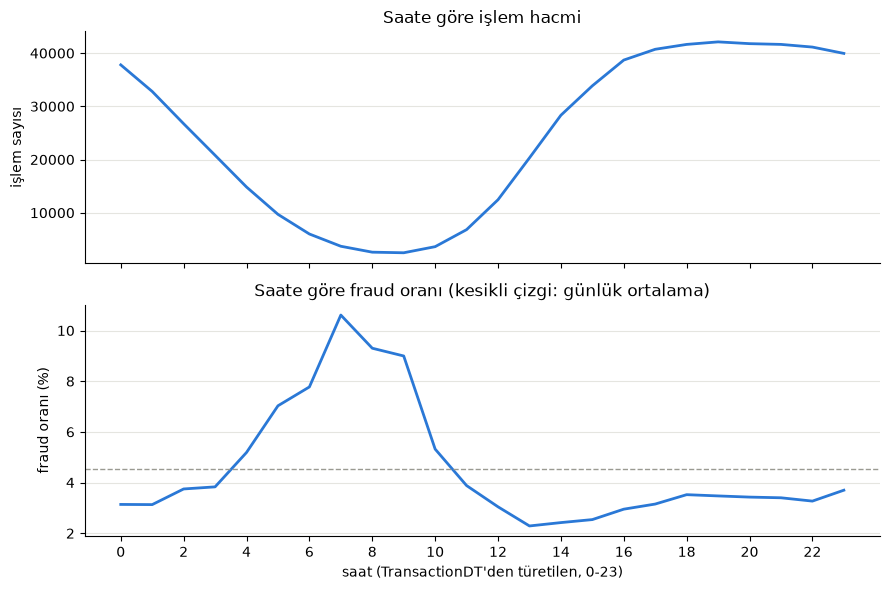

In [26]:
import matplotlib.pyplot as plt

SERIES_COLOR = "#2a78d6"

fig, (ax_volume, ax_fraud) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax_volume.plot(hourly["hour_of_day"], hourly["transaction_count"], color=SERIES_COLOR, linewidth=2)
ax_volume.set_ylabel("işlem sayısı")
ax_volume.set_title("Saate göre işlem hacmi")
ax_volume.spines[["top", "right"]].set_visible(False)
ax_volume.grid(axis="y", color="#e5e5e0", linewidth=0.8)

ax_fraud.plot(hourly["hour_of_day"], hourly["fraud_rate_pct"], color=SERIES_COLOR, linewidth=2)
ax_fraud.axhline(hourly["fraud_rate_pct"].mean(), color="#9a9a92", linewidth=1, linestyle="--")
ax_fraud.set_ylabel("fraud oranı (%)")
ax_fraud.set_xlabel("saat (TransactionDT'den türetilen, 0-23)")
ax_fraud.set_title("Saate göre fraud oranı (kesikli çizgi: günlük ortalama)")
ax_fraud.spines[["top", "right"]].set_visible(False)
ax_fraud.grid(axis="y", color="#e5e5e0", linewidth=0.8)
ax_fraud.set_xticks(range(0, 24, 2))

fig.tight_layout()
plt.show()

**Bulgu:** işlem hacmi ile fraud oranı ters yönde hareket ediyor. Hacmin en düşük olduğu saatler (04:00–09:00, günün en sakin dilimi) fraud oranının **en yüksek** olduğu saatlerle çakışıyor (saat 7'de %10,61, genel ortalamanın \~3 katı); hacmin zirve yaptığı akşam saatlerinde (15:00–23:00) fraud oranı %2,3–3,7 bandında, genel ortalamaya yakın.

Bu, `isFraud`'un yalnızca betimleyici kullanıldığı bir bulgu; hiçbir tipleme/temizlik kararını etkilemiyor, ama sonraki (denetimsiz) anomali tespiti katmanı için önemli bir sinyal: **saat**, zaman bazlı bir özellik olarak eklendiğinde muhtemelen ayırt edici olacak, çünkü düşük hacimli saatlerde işlem başına anomali olasılığı yapısal olarak daha yüksek görünüyor.

## 7. Yüksek Cardinality Analizi

`src/services/analyzers/cardinality.py`, `column_types.py`'nin ürettiği `classified` tablosunu yeniden kullanıyor; nunique/unique_ratio zaten hesaplı. İki çıktı üretiyor:

1. **Cardinality kademesi**: `binary` (≤2) / `low` (≤10) / `medium` (≤50) / `high` (≤1000) / `very_high` (>1000), artı ayrı bir **quasi-identifier** bayrağı (`unique_ratio > 0,9`).
2. **Kodlama önerisi:** yine iki katmanlı (bölüm 4'teki desenin aynısı): istatistiksel taban kural (kademeye göre one-hot / frekans kodlama / düşür) + `card1/2/3/5`, `addr1/2`, `DeviceInfo`, `DeviceType`, `P_emaildomain`, `R_emaildomain` için açık bir domain-hint listesi (`ENTITY_KEY_COLUMN_HINTS`). Bunlar yüksek kardinaliteli diye düşürülecek "gürültü" değil, sonraki anomali tespiti katmanının toplulaştırma anahtarı olacak kolonlar.

In [27]:
from src.services.analyzers.cardinality import compute_cardinality

cardinality = compute_cardinality(classified)
cardinality["cardinality_tier"].value_counts().to_frame(name="kolon sayısı")

,kolon sayısı
cardinality_tier,
medium,118
high,106
low,93
very_high,91
binary,26


In [28]:
cardinality["encoding_recommendation"].value_counts().to_frame(name="kolon sayısı")

,kolon sayısı
encoding_recommendation,
one-hot,234
"n/a: continuous numeric, no encoding needed",96
frequency encoding,83
preserve as entity key,10
hashing or entity-key candidate: needs manual review,8
n/a: handled separately (identifier/target/timestamp),3


### Varlık anahtarı olarak korunacak 10 kolon

Önemli bir ayrım: yüksek kardinalite "düşürülecek kötü kolon" anlamına gelmiyor.

In [29]:
entity_keys = cardinality[cardinality["encoding_recommendation"] == "preserve as entity key"]
entity_keys.reset_index(drop=True)

,column,semantic_type,nunique,unique_ratio,cardinality_tier,is_quasi_identifier,encoding_recommendation
0,card1,numeric_encoded_categorical,13553,0.022950,very_high,False,preserve as entity key
1,card2,numeric_encoded_categorical,500,0.000860,high,False,preserve as entity key
2,card3,numeric_encoded_categorical,114,0.000194,high,False,preserve as entity key
3,card5,numeric_encoded_categorical,119,0.000203,high,False,preserve as entity key
4,addr1,numeric_encoded_categorical,332,0.000633,high,False,preserve as entity key
5,addr2,near_constant,74,0.000141,high,False,preserve as entity key
6,P_emaildomain,categorical,59,0.000119,high,False,preserve as entity key
7,R_emaildomain,categorical,60,0.000437,high,False,preserve as entity key
8,DeviceType,binary_flag,2,0.000014,binary,False,preserve as entity key
9,DeviceInfo,high_cardinality_text,1786,0.015051,very_high,False,preserve as entity key


`card1` (13553 farklı değer) ve `DeviceInfo` (1786 farklı değer) tek başına one-hot'a sokulsa binlerce sütun üretir ve hiçbir şey öğrenmez. Ama aynı kolonlar, "bu cihazdan/bu karttan başka hangi işlemler geldi" diye gruplama anahtarı olarak kullanıldığında (örn. aynı `card1`'den kısa sürede çok sayıda farklı `addr1`'e işlem) anomali tespitinin en değerli sinyallerinden biri olur; bu yüzden encoding değil, **saklama** öneriliyor.

### Quasi-identifier kontrolü (unique_ratio > 0,9)

In [30]:
cardinality[cardinality["is_quasi_identifier"]].reset_index(drop=True)

,column,semantic_type,nunique,unique_ratio,cardinality_tier,is_quasi_identifier,encoding_recommendation
0,TransactionID,identifier,590540,1.000000,very_high,True,n/a: handled separately (identifier/target/timestamp)
1,TransactionDT,timestamp_offset,573349,0.970889,very_high,True,n/a: handled separately (identifier/target/timestamp)


Sadece `TransactionID` ve `TransactionDT` bu eşiği geçiyor; ikisi de zaten beklenen, ayrı ele alınan kolonlar (identifier / timestamp_offset). Başka hiçbir kolon kazara satır kimliğini sızdırmıyor; bu, birleştirme adımının veriye yeni bir "gizli id" eklemediğinin dolaylı bir doğrulaması.

### Elle incelenmesi gereken 8 sınır durumu

In [31]:
cardinality[cardinality["encoding_recommendation"].str.startswith("hashing")].reset_index(drop=True)

,column,semantic_type,nunique,unique_ratio,cardinality_tier,is_quasi_identifier,encoding_recommendation
0,dist1,numeric_encoded_categorical,2651,0.011126,very_high,False,hashing or entity-key candidate: needs manual review
1,dist2,numeric_encoded_categorical,1751,0.046536,very_high,False,hashing or entity-key candidate: needs manual review
2,V96,numeric_encoded_categorical,1410,0.002389,very_high,False,hashing or entity-key candidate: needs manual review
3,V102,numeric_encoded_categorical,1285,0.002177,very_high,False,hashing or entity-key candidate: needs manual review
4,V150,numeric_encoded_categorical,1996,0.024356,very_high,False,hashing or entity-key candidate: needs manual review
5,V178,numeric_encoded_categorical,1236,0.008852,very_high,False,hashing or entity-key candidate: needs manual review
6,V294,numeric_encoded_categorical,1286,0.002178,very_high,False,hashing or entity-key candidate: needs manual review
7,V323,numeric_encoded_categorical,1411,0.017134,very_high,False,hashing or entity-key candidate: needs manual review


`dist1`/`dist2` (mesafe özellikleri) ve 6 V-kolonu: `very_high` kademede (1000'den fazla farklı değer) ama quasi-identifier değiller (unique_ratio hepsinde <%5); yani `card1` gibi net bir "varlık kimliği" de değiller, sıradan yüksek-çözünürlüklü sayısal kodlar da olabilirler. Domain hint listesinde yoklar çünkü bu kolonların ne temsil ettiği (Vesta tarafından) belgelenmemiş; bölüm 4'teki `numeric_encoded_categorical` tartışmasıyla aynı dürüstlük: istatistik burada kesin bir cevap veremiyor, elle incelemeyi öneriyoruz, otomatik bir varsayımda bulunmuyoruz.

## Sonuç: Case 1'in altı analizinin özeti

| # | Analiz | Ana bulgu |
|---|---|---|
| 1 | Merge | 590.540 satır, 435 kolon; identity kapsaması %24,42; satır çoğalması yok. |
| 2 | Eksik veri | 208/434 kolon %70+ eksik; 27 desen grubu bulundu, 6'sı join-kaynaklı yapısal (identity kapsamama oranına ±%1 yakın); satır başına ortalama 195,6 kolon boş. |
| 3 | Otomatik kolon tipleme | İki katmanlı (istatistik + domain hint); `numeric_encoded_categorical` (276 kolon) hem gerçek kategorik kodları (`card1`/`addr1`) hem düşük-kardinaliteli V-sayım özelliklerini kapsıyor; "seyreklik" bu ikisini ayırmıyor (test edildi, hipotez reddedildi). |
| 4 | Veri kalitesi | Genel skor 98,07/100; sıfır tekrarlı satır/ID/kolon, tüm iş kuralları temiz; `id_25` aykırı-değer analizinde tipleme sınırında kaldığı ortaya çıktı (çapraz doğrulama). |
| 5 | Dağılımlar | 96 sayısal kolonun 91'i log-dönüşüm adayı; saat bazlı fraud oranı hacimle ters orantılı (saat 7: %10,61, saat 13: %2,29); zaman, olası bir anomali sinyali. |
| 6 | Yüksek cardinality | 10 kolon varlık anahtarı olarak korunuyor (`card1-3/5`, `addr1/2`, `DeviceInfo`, `DeviceType`, e-posta alan adları); düşürülecek gürültü değil, sadece 2 quasi-identifier var (beklenen ikisi), sızıntı yok. |

**Ortak ilke:** `isFraud` hiçbir analizde tipleme/temizlik/kodlama kararını yönlendirmedi; sadece bölüm 6'da (saat bazlı fraud oranı) betimleyici olarak kullanıldı. Bu, sonraki denetimsiz anomali tespiti katmanının etiketten bağımsız kalması için bilinçli bir tercih.

**Sonraki katmana devreden çıktılar:** `classified` (kolon başına semantik tip), `cardinality` (kodlama önerileri + varlık anahtarları), ve bu notebook'taki her bölümün ürettiği bulgu tabloları; hepsi `data/processed/merged_transactions.parquet` üzerinden yeniden üretilebilir.